In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

c:\Users\Kim_W\BI_Assignment\BI_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Predicting weather a flight will arrive more than 15 minutes late

In [2]:
data_2003 = pd.read_csv('data_2003_2.csv', low_memory = False)
data_2003

,Unnamed: 0,CRSElapsedTime,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,time_of_day_CRSDepTime,time_of_day_CRSArrTime,Weekend,Season,Delay
0,0,138.0,29.0,ORD,MSY,837,5,17,3,4,0,1,1
1,1,239.0,-4.0,OAK,ORD,1835,13,13,2,3,0,1,0
2,2,239.0,0.0,OAK,ORD,1835,5,9,2,3,1,1,0
3,3,239.0,-4.0,OAK,ORD,1835,7,14,2,3,0,1,1
4,4,97.0,3.0,IAD,BOS,413,7,29,3,4,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1839026,1839026,98.0,37.0,SRQ,ATL,445,11,12,2,2,0,1,1
1839027,1839027,219.0,26.0,LAS,CVG,1678,7,17,3,4,0,1,1
1839028,1839028,131.0,44.0,AUS,ATL,813,10,18,2,2,0,1,1
1839029,1839029,96.0,50.0,ATL,IND,432,8,21,4,4,0,1,1


In [3]:
data_2003 = data_2003.drop(['Unnamed: 0'], axis=1)

## 1. Training, Test & Validation Set

In [4]:
X_2003 = data_2003.drop(columns = ['Delay', 'CRSElapsedTime', 'Distance', 'Weekend', 'Season', 'TaxiIn'], axis=1)
y_2003 = data_2003['Delay']

In [5]:
rus = RandomUnderSampler(sampling_strategy=0.7, random_state=42)
X_2003_res, y_2003_res = rus.fit_resample(X_2003, y_2003)

In [6]:
categorical_cols_2003 = X_2003_res.select_dtypes(include='object').columns

numerical_cols_2003 = X_2003_res.select_dtypes(exclude='object').columns

In [7]:
X_2003_categorical_encoded = pd.get_dummies(X_2003_res[categorical_cols_2003], drop_first=True, dummy_na=False)

X_2003_processed = pd.concat([X_2003_res[numerical_cols_2003], X_2003_categorical_encoded], axis=1)

In [8]:
Scaler_2003 = StandardScaler()
X_2003_scaled = Scaler_2003.fit_transform(X_2003_processed)

In [9]:
X_train_2003, X_temp_2003, y_train_2003, y_temp_2003 = train_test_split(X_2003_scaled, y_2003_res, test_size=0.30, random_state=42, stratify=y_2003_res)
X_val_2003, X_test_2003, y_val_2003, y_test_2003 = train_test_split(X_temp_2003, y_temp_2003, test_size=0.50, random_state=42, stratify=y_temp_2003)

In [10]:
print("Data_2003 preparation and splitting complete.")
print(f"X_train_2003 shape: {X_train_2003.shape}")
print(f"X_val_2003 shape: {X_val_2003.shape}")
print(f"X_test_2003 shape: {X_test_2003.shape}")
print(f"y_train_2003 shape: {y_train_2003.shape}")
print(f"y_val_2003 shape: {y_val_2003.shape}")
print(f"y_test_2003 shape: {y_test_2003.shape}")

Data_2003 preparation and splitting complete.
X_train_2003 shape: (968079, 556)
X_val_2003 shape: (207446, 556)
X_test_2003 shape: (207446, 556)
y_train_2003 shape: (968079,)
y_val_2003 shape: (207446,)
y_test_2003 shape: (207446,)


## 2. Model Generation

In [11]:
def create_nn_model(input_shape, hp):
    
    Dense = tf.keras.layers.Dense
    Dropout = tf.keras.layers.Dropout
        
    model = tf.keras.Sequential()
    model.add(keras.layers.Input(shape=(input_shape,)))
    model.add(Dense(units=hp.Int("units_layer1", min_value=32, max_value=256, step=32),
                    activation='relu'))
    model.add(Dropout(rate=hp.Float("dropout_rate", min_value = 0.0, max_value = 0.5, step=0.1)))
    model.add(Dense(units=hp.Int("units_layer2", min_value=32, max_value=256, step=32),
                    activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(hp.Float("learning_rate",
            min_value=1e-4,
            max_value=1e-2,
            sampling="log")), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [12]:
input_shape_2003 = X_train_2003.shape[1]

In [13]:
tuner = kt.BayesianOptimization(
    lambda hp: create_nn_model(input_shape_2003, hp),
    objective='val_loss',
    max_trials=8,
    executions_per_trial=1,
    directory='Tuning_2003',
    project_name='keras_tuner_demo',
    overwrite=True)

In [23]:
tuner.search(X_train_2003, y_train_2003, epochs=8, validation_data=(X_val_2003, y_val_2003))

Trial 8 Complete [00h 25m 19s]
val_loss: 0.3700513243675232

Best val_loss So Far: 0.3700513243675232
Total elapsed time: 03h 29m 24s


In [24]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best units1: {best_hp.get('units_layer1')}")
print(f"Best dropout_rate: {best_hp.get('dropout_rate')}")
print(f"Best units1: {best_hp.get('units_layer2')}")
print(f"Best learning rate: {best_hp.get('learning_rate')}")

Best units1: 192
Best dropout_rate: 0.1
Best units1: 160
Best learning rate: 0.00035029019305339175


## 3. Fitting Model

In [25]:
early_stopping = EarlyStopping(monitor='val_loss', patience= 5, restore_best_weights = True)

In [ ]:
model_2003 = tuner.hypermodel.build(best_hp)
model_2003.fit(X_train_2003, y_train_2003, class_weight=class_weights_2003, epochs=20, batch_size=32, validation_data=(X_val_2003, y_val_2003), callbacks=[early_stopping])

Epoch 1/20
30253/30253 ━━━━━━━━━━━━━━━━━━━━ 187s 6ms/step - accuracy: 0.8224 - loss: 0.4123 - val_accuracy: 0.8327 - val_loss: 0.3868
Epoch 2/20
30253/30253 ━━━━━━━━━━━━━━━━━━━━ 195s 6ms/step - accuracy: 0.8315 - loss: 0.3911 - val_accuracy: 0.8336 - val_loss: 0.3814
Epoch 3/20
30253/30253 ━━━━━━━━━━━━━━━━━━━━ 36636s 1s/step - accuracy: 0.8330 - loss: 0.3872 - val_accuracy: 0.8327 - val_loss: 0.3841
Epoch 4/20
30253/30253 ━━━━━━━━━━━━━━━━━━━━ 375s 11ms/step - accuracy: 0.8337 - loss: 0.3851 - val_accuracy: 0.8337 - val_loss: 0.3868
Epoch 5/20
24213/30253 ━━━━━━━━━━━━━━━━━━━━ 3:39 36ms/step - accuracy: 0.8347 - loss: 0.3821

## 4. Model Evaluaiton

In [ ]:
loss_2003, accuracy_2003 = model_2003.evaluate(X_test_2003, y_test_2003)
print(f"Test Loss for 2003 model: {loss_2003:.4f}")
print(f"Test Accuracy for 2003 model: {accuracy_2003:.4f}")

6483/6483 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - accuracy: 0.8362 - loss: 0.3749
Test Loss for 2003 model: 0.3749
Test Accuracy for 2003 model: 0.8362


6483/6483 ━━━━━━━━━━━━━━━━━━━━ 6s 921us/step


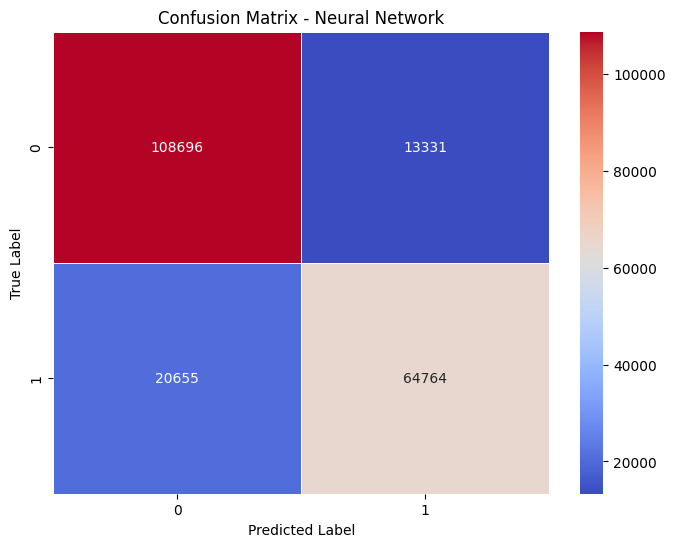

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
y_pred_probs = model_2003.predict(X_test_2003)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test_2003, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d', linewidths=0.5)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Neural Network")
plt.show()

In [ ]:
model_2003.save("2003_model.h5")